<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/dz_topic_10_Manzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pickle
import pandas as pd

file_path = "/content/drive/MyDrive/Домашнєзавдання/ML/mod_05_topic_10_various_data.pkl"

with open(file_path, 'rb') as fl:
    datasets = pickle.load(fl)

autos = datasets['autos']

autos.head()




,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


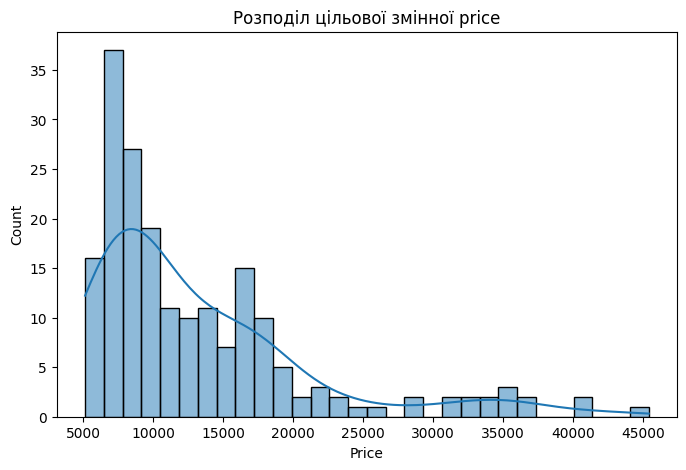

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(autos['price'], bins=30, kde=True)
plt.title("Розподіл цільової змінної price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()





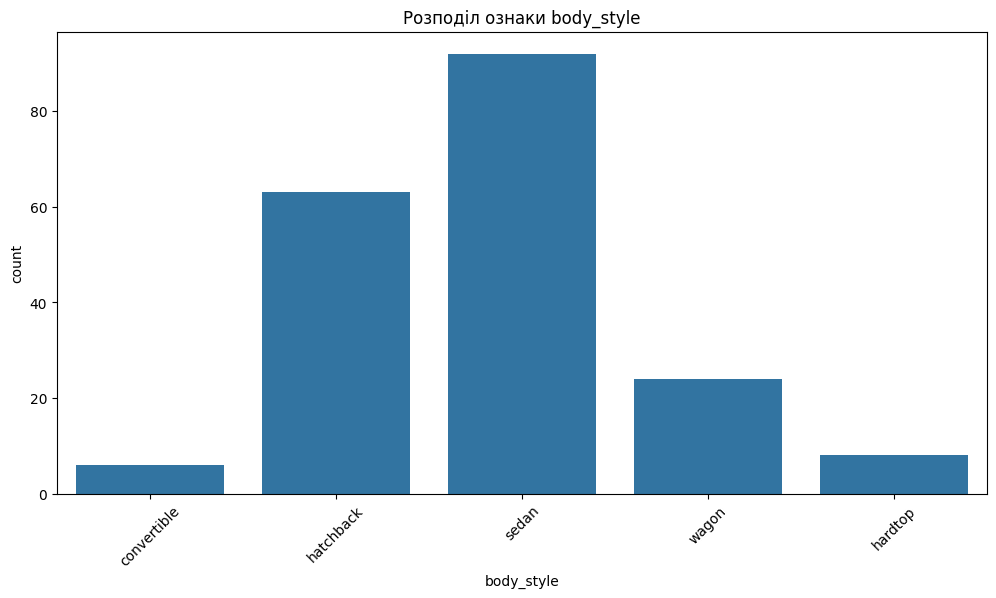

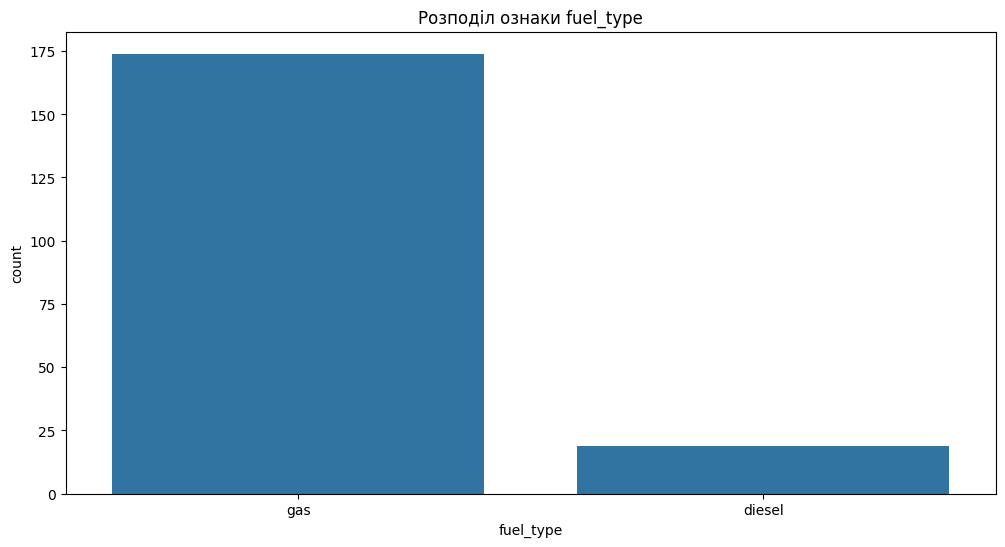

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(data=autos, x='body_style')
plt.title("Розподіл ознаки body_style")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=autos, x='fuel_type')
plt.title("Розподіл ознаки fuel_type")
plt.show()


/tmp/ipykernel_1769/2024659827.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")


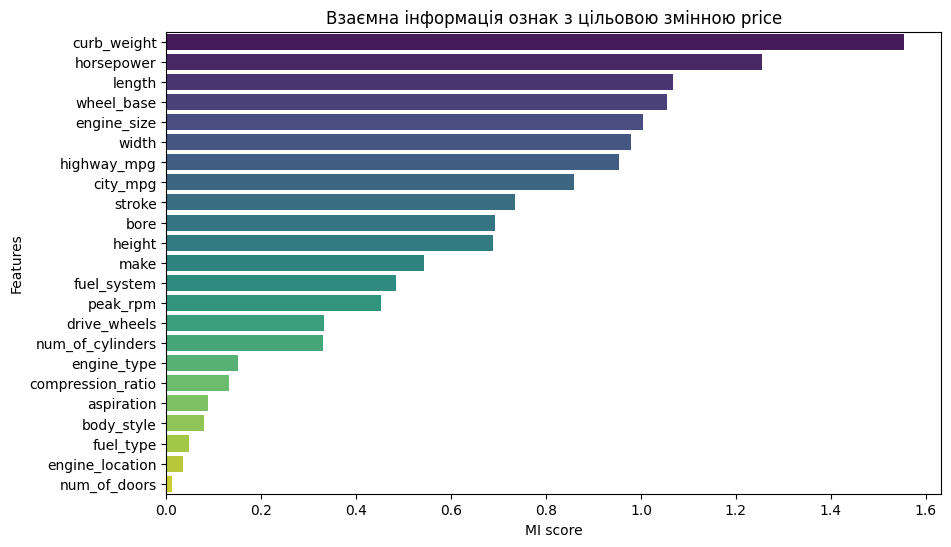

In [15]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

df = autos.copy()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('price', axis=1)
y = df['price']

mi_scores = mutual_info_regression(X, y, discrete_features=True)

mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
mi_series

plt.figure(figsize=(10,6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
plt.title("Взаємна інформація ознак з цільовою змінною price")
plt.xlabel("MI score")
plt.ylabel("Features")
plt.show()


/tmp/ipykernel_1769/2898462302.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, palette="magma")


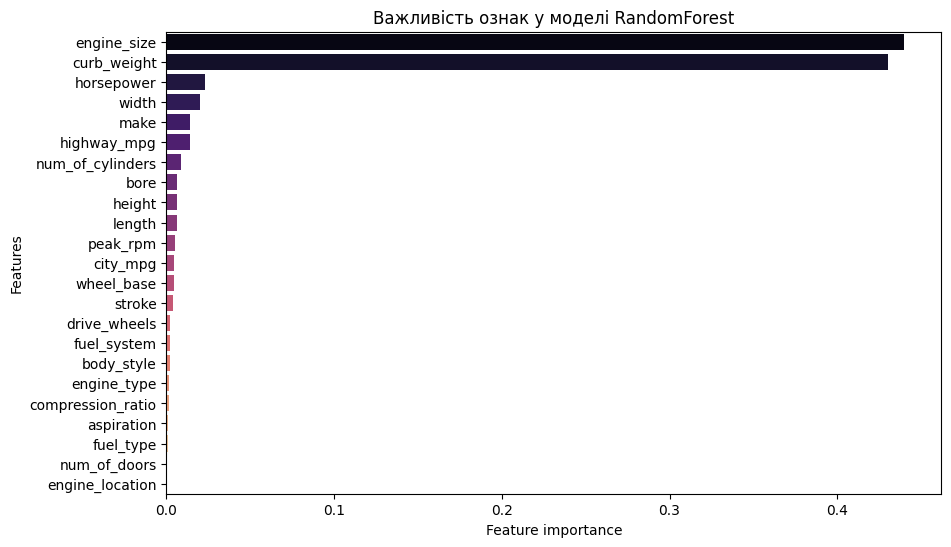

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = autos.copy()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_importances

plt.figure(figsize=(10,6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette="magma")
plt.title("Важливість ознак у моделі RandomForest")
plt.xlabel("Feature importance")
plt.ylabel("Features")
plt.show()


<Figure size 1200x600 with 0 Axes>

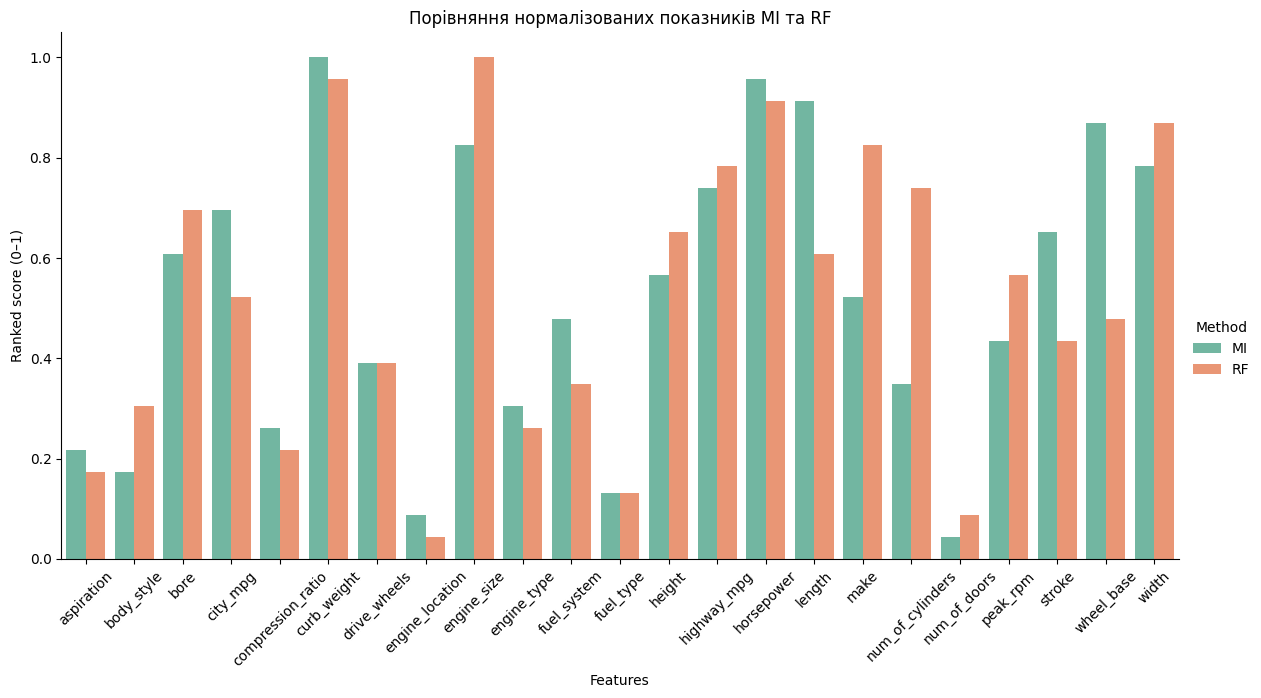

In [18]:

comparison_df = pd.DataFrame({
    'MI': mi_series,
    'RF': rf_importances
})

comparison_scaled = comparison_df.rank(pct=True)

comparison_scaled

comparison_melted = comparison_scaled.reset_index().melt(
    id_vars='index',
    value_vars=['MI', 'RF'],
    var_name='Method',
    value_name='Score'
)

plt.figure(figsize=(12,6))
sns.catplot(
    data=comparison_melted,
    kind="bar",
    x="index",
    y="Score",
    hue="Method",
    height=6,
    aspect=2,
    palette="Set2"
)
plt.title("Порівняння нормалізованих показників MI та RF")
plt.xlabel("Features")
plt.ylabel("Ranked score (0–1)")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_1769/2213994300.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gb_importances.values, y=gb_importances.index, palette="coolwarm")


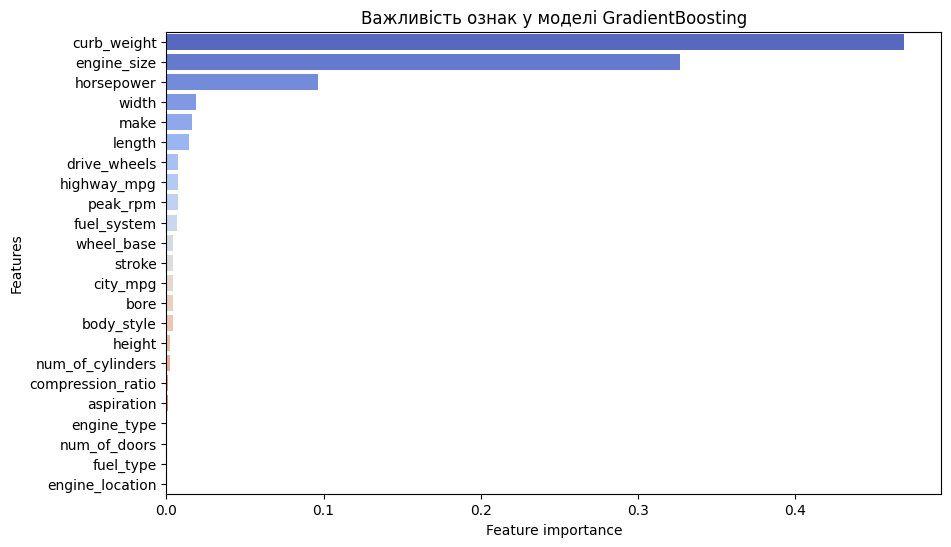

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

X = df.drop('price', axis=1)
y = df['price']

gb = GradientBoostingRegressor(n_estimators=300, random_state=42)
gb.fit(X_train, y_train)

gb_importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
gb_importances

plt.figure(figsize=(10,6))
sns.barplot(x=gb_importances.values, y=gb_importances.index, palette="coolwarm")
plt.title("Важливість ознак у моделі GradientBoosting")
plt.xlabel("Feature importance")
plt.ylabel("Features")
plt.show()


##Аналіз та висновки

Взаємна інформація (MI) показує статистичну залежність між ознаками та цільовою змінною price. Це міра того, наскільки ознака сама по собі пов’язана з ціною авто.

Важливість ознак у моделі (RandomForest) відображає, наскільки ознака реально використовується деревами при побудові прогнозу. Це модельно-залежний показник, який враховує комбінації ознак.

Деякі ознаки мають високу MI, але низьку важливість у моделі — вони пов’язані з ціною, проте їхня інформація дублюється іншими ознаками, і модель не використовує їх активно.

Інші ознаки мають низьку MI, але високу важливість у моделі — вони не є сильними самостійно, але у взаємодії з іншими ознаками модель знаходить у них корисні патерни.

Використання .rank(pct=True) дозволило привести обидва набори показників до єдиної шкали (0–1) і зробити їх порівнянними.

Візуалізація grouped barplots чітко показує відмінності між статистичною «корисністю» ознак та їхньою практичною важливістю у моделі.

Корисність ознак з точки зору взаємної інформації може суттєво відрізнятися від їхньої важливості у моделі для прийняття рішень.
Для якісного відбору ознак варто комбінувати обидва підходи:

статистичні міри (MI),

модельні оцінки (RandomForest, GradientBoosting).

Це дозволяє отримати більш збалансоване уявлення про значення ознак і підвищити ефективність побудови моделей машинного навчання.